In [1]:
import pandas as pd
agriculture_df= pd.read_csv("agriculture_yield_dataset.csv")

In [ ]:
# Dataset Overview
agriculture_df.shape
agriculture_df.columns
agriculture_df.head(10)

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


In [ ]:
agriculture_df.dtypes


,0
rainfall_mm,float64
temperature_c,float64
fertilizer_kg,float64
irrigation_hours,float64
soil_ph,float64
crop_type,object
soil_type,object
yield_ton_per_hectare,float64


In [ ]:
agriculture_df.isna().sum()

,0
rainfall_mm,0
temperature_c,0
fertilizer_kg,0
irrigation_hours,0
soil_ph,0
crop_type,0
soil_type,0
yield_ton_per_hectare,0


In [ ]:
summary = agriculture_df.describe()
highest_mean = summary.loc['mean'].idxmax()
highest_std = summary.loc['std'].idxmax()
print(f"The column with the highest mean is {highest_mean}")
print(f"The column with the highest standard deviation is {highest_std}")


The column with the highest mean is rainfall_mm
The column with the highest standard deviation is rainfall_mm


In [ ]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'


In [ ]:
fig = px.histogram(
    agriculture_df,
    x='rainfall_mm',
    marginal='box',
    nbins=20,
    title='Distribution of Rainfall'
)

fig.update_layout(bargap=0.1)

fig.show()
#the graph is almost symmetrical
#no outliers
#max rainfall lies between 800-900

In [ ]:
fig = px.histogram(
    agriculture_df,
    x='temperature_c',
    marginal='box',
    nbins=20,
    title='Distribution of Temperature'
)

fig.update_layout(bargap=0.1)

fig.show()

In [ ]:
fig = px.histogram(
    agriculture_df,
    x='fertilizer_kg',
    marginal='box',
    nbins=20,
    title='Distribution of Fertilizer Usage'
)

fig.update_layout(bargap=0.1)

fig.show()

In [ ]:
fig = px.histogram(
    agriculture_df,
    x='yield_ton_per_hectare',
    marginal='box',
    nbins=20,
    title='Distribution of Crop Yield'
)

fig.update_layout(bargap=0.1)

fig.show()


In [ ]:
agriculture_df['crop_type'].value_counts()

,count
crop_type,
Cotton,311
Soybean,306
Wheat,303
Rice,293
Maize,287


In [ ]:
fig = px.histogram(
    agriculture_df,
    x='crop_type',
    title='Crop Type Distribution'
)

fig.update_layout(
    xaxis_title='Crop Type',
    yaxis_title='Count'
)

fig.show()
# Cotton crop appears most frequently

In [ ]:
agriculture_df['soil_type'].value_counts()

,count
soil_type,
Clay,534
Sandy,492
Loamy,474


In [ ]:
fig= px.histogram(
    agriculture_df,
    x='soil_type',
    title='Soil type distribution'
)
fig.update_layout(
    xaxis_title='Soil Type',
    yaxis_title='Count'
)
fig.show()
# Clay soil type is most common

In [ ]:
fig = px.histogram(
    agriculture_df,
    x='yield_ton_per_hectare',
    marginal='box',
    nbins=20,
    title='Distribution of Crop Yield'
)

fig.update_layout(bargap=0.1)

fig.show()
#Distribution is approximately normal and there no noticeable outliers

In [ ]:
fig = px.scatter(
    agriculture_df,
    x='rainfall_mm',
    y='yield_ton_per_hectare',
    title='Rainfall vs Crop Yield'
)

fig.show()

In [ ]:
fig= px.scatter(
    agriculture_df,
    x ='fertilizer_kg',
    y= 'yield_ton_per_hectare',
    title='Fertilizer Usage vs Crop Yield'
)
fig.show()


In [ ]:
# rainfall_mm appears to have a stronger relationship with yield as compared to fertilizer_kg as the scatter plot of rainfall_mm vs yield_ton_per_hectare has clear upward trend

In [8]:
#Group-Based Analysis
avg =agriculture_df.groupby('crop_type')['yield_ton_per_hectare'].mean()
print(avg)
print("crop has highest average yield:", avg.idxmax())

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64
crop has highest average yield: Rice


In [9]:
avg= agriculture_df.groupby('soil_type')['yield_ton_per_hectare'].mean()
print(avg)
print("Soil type that has max average yield is:", avg.idxmax())

soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64
Soil type that has max average yield is: Loamy


In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

agriculture_df['crop_type'] = le.fit_transform(agriculture_df['crop_type'])

agriculture_df['soil_type'] = le.fit_transform(agriculture_df['soil_type'])

In [ ]:
corr_matrix = agriculture_df.corr()

corr_matrix


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
rainfall_mm,1.000000,0.026721,0.002558,0.010877,0.006916,0.039569,-0.007904,0.553704
temperature_c,0.026721,1.000000,0.037468,0.007114,0.001513,0.041556,-0.008634,-0.022559
fertilizer_kg,0.002558,0.037468,1.000000,-0.010497,0.010001,0.027912,0.018753,0.278043
irrigation_hours,0.010877,0.007114,-0.010497,1.000000,0.009307,-0.008147,-0.046006,0.542664
soil_ph,0.006916,0.001513,0.010001,0.009307,1.000000,-0.000765,-0.035217,0.024412
crop_type,0.039569,0.041556,0.027912,-0.008147,-0.000765,1.000000,0.002310,0.154771
soil_type,-0.007904,-0.008634,0.018753,-0.046006,-0.035217,0.002310,1.000000,-0.227301
yield_ton_per_hectare,0.553704,-0.022559,0.278043,0.542664,0.024412,0.154771,-0.227301,1.000000


<Axes: >

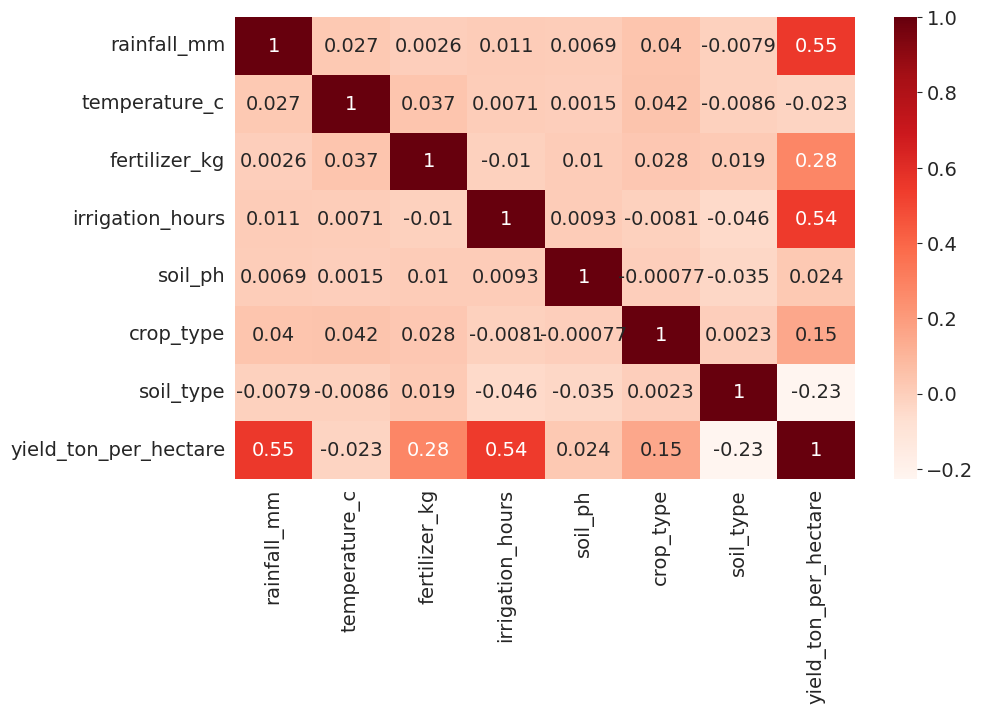

In [ ]:
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='Reds')


In [12]:
cat_cols= agriculture_df.select_dtypes(include='object').columns
print(cat_cols)
agri_encoded= pd.get_dummies(
    agriculture_df,
    columns=['soil_type', 'crop_type'],
    drop_first= True
)
agri_encoded.head()

Index(['crop_type', 'soil_type'], dtype='object')


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,soil_type_Loamy,soil_type_Sandy,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,True,False,False,False
1,772.8,34.6,247.2,10.0,6.5,6.24,False,True,True,False,False,False
2,970.9,36.3,168.4,7.3,6.4,4.77,False,True,False,False,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,True,False,False,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
agriculture_df['crop_type'] = le.fit_transform(agriculture_df['crop_type'])
agriculture_df['soil_type'] = le.fit_transform(agriculture_df['soil_type'])
#Input feature
X = agriculture_df.drop('yield_ton_per_hectare', axis=1)
#Target variable
y = agriculture_df['yield_ton_per_hectare']

In [24]:
#Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1200, 7)
X_test shape: (300, 7)
y_train shape: (1200,)
y_test shape: (300,)


In [25]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
#display the intercept
print("Intercept:", model.intercept_)

Intercept: 1.9705093543420662


In [27]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
print( coefficients)

            Feature  Coefficient
0       rainfall_mm     0.002083
1     temperature_c    -0.009600
2     fertilizer_kg     0.004713
3  irrigation_hours     0.201737
4           soil_ph     0.003532
5         crop_type     0.090973
6         soil_type    -0.247006


In [29]:
 coefficients.loc[coefficients['Coefficient'].idxmax()]

,3
Feature,irrigation_hours
Coefficient,0.201737
